In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression , LinearRegression
from sklearn.ensemble import RandomForestClassifier , RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, f1_score, accuracy_score, mean_squared_error


from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [2]:

df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/ADP_SONY/ADP_34/data/vlbw.csv')
df.head()

,lowph,pltct,race,bwt,gest,inout,twn,meth,toc,delivery,vent,pneumo,pda,cld,pvh,ivh,ipe,sex,dead
0,NaN,100.0,white,1250.0,35.0,born at Duke,0.0,0.0,0.0,abdominal,0.0,0.0,0.0,0.0,NaN,NaN,NaN,female,0
1,7.250000,244.0,white,1370.0,32.0,born at Duke,0.0,1.0,0.0,abdominal,0.0,0.0,0.0,0.0,NaN,NaN,NaN,female,0
2,7.059998,114.0,black,620.0,23.0,born at Duke,0.0,0.0,1.0,vaginal,1.0,0.0,0.0,NaN,NaN,NaN,NaN,female,1
3,7.250000,182.0,black,1480.0,32.0,born at Duke,0.0,1.0,0.0,vaginal,0.0,0.0,0.0,0.0,NaN,NaN,NaN,male,0
4,6.969997,54.0,black,925.0,28.0,born at Duke,0.0,0.0,0.0,abdominal,1.0,1.0,0.0,0.0,definite,definite,NaN,female,1


In [3]:
from itertools import combinations
lst = ['pvh','ivh','ipe']

res = []
for v1, v2 in list(combinations(lst, 2)) : 
    tab = pd.crosstab(df[v1], df[v2])
    s, p, _ , _ = chi2_contingency(tab)
    decision = '유의하다 (독립이지 않다)' if p < 0.05 else '유의하지 않다 (독립이다)'
    res.append({
        'Col1' : v1, 
        'Col2' : v2, 
        'Pvalue' : p, 
        'decision' : decision
    })

print(pd.DataFrame(res))

  Col1 Col2        Pvalue        decision
0  pvh  ivh  4.049839e-09  유의하다 (독립이지 않다)
1  pvh  ipe  7.848100e-02  유의하지 않다 (독립이다)
2  ivh  ipe  4.632591e-12  유의하다 (독립이지 않다)


In [4]:
def bleed(x) :
  if x['pvh'] == 'absent' and x['ivh'] == 'absent' and x['ipe'] == 'absent' :
    return 0

  elif x[['pvh','ivh','ipe']].isin(['possible','definite']).any() :
    return 1

  else :
    return np.nan

df['Bleed']= df.apply(bleed, axis = 1)
df['Bleed'].value_counts(dropna = False)

Bleed
0.0    306
1.0    220
NaN    145
Name: count, dtype: int64

In [5]:
#Ind -pvh,ivh,ipe를 제외한 모든 컬럼이 결측치가 없으면 0, bleed가 결측이면 1, 나머지는 2
def ind(x) : 
    if x.drop(columns = ['pvh','ivh','ipe']).isnull().sum() == 0 : 
        return 0 
    elif pd.isna(x['Bleed']) : 
        return 1
    else : 
        return 2 

df['Ind'] = df.apply(ind, axis = 1)
df.head()

,lowph,pltct,race,bwt,gest,inout,twn,meth,toc,delivery,...,pneumo,pda,cld,pvh,ivh,ipe,sex,dead,Bleed,Ind
0,NaN,100.0,white,1250.0,35.0,born at Duke,0.0,0.0,0.0,abdominal,...,0.0,0.0,0.0,NaN,NaN,NaN,female,0,NaN,1
1,7.250000,244.0,white,1370.0,32.0,born at Duke,0.0,1.0,0.0,abdominal,...,0.0,0.0,0.0,NaN,NaN,NaN,female,0,NaN,1
2,7.059998,114.0,black,620.0,23.0,born at Duke,0.0,0.0,1.0,vaginal,...,0.0,0.0,NaN,NaN,NaN,NaN,female,1,NaN,1
3,7.250000,182.0,black,1480.0,32.0,born at Duke,0.0,1.0,0.0,vaginal,...,0.0,0.0,0.0,NaN,NaN,NaN,male,0,NaN,1
4,6.969997,54.0,black,925.0,28.0,born at Duke,0.0,0.0,0.0,abdominal,...,1.0,0.0,0.0,definite,definite,NaN,female,1,1.0,2


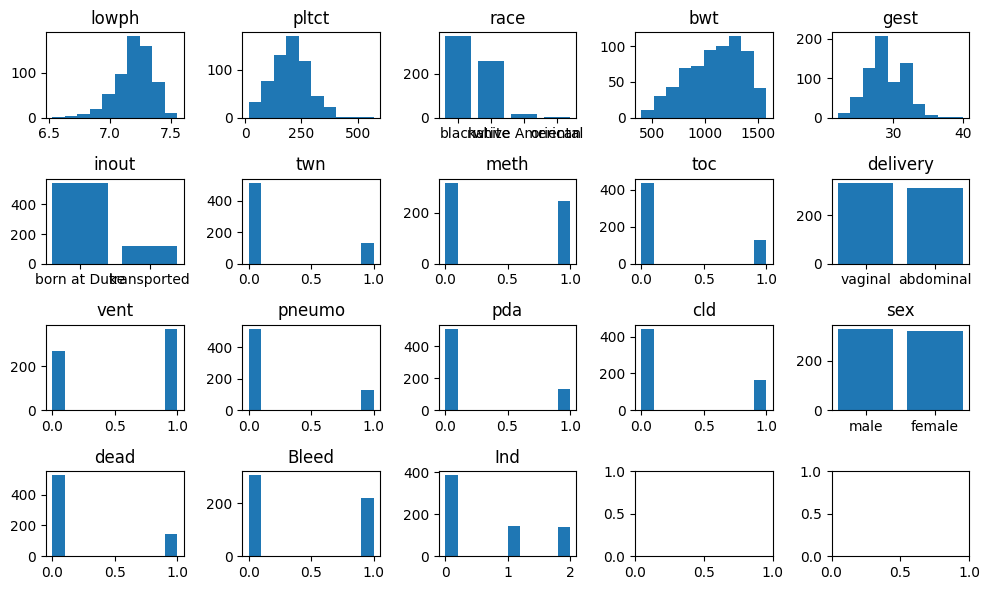

In [6]:
cols = ['pvh','ivh','ipe']


df2 = df.drop(cols, axis = 1).copy()

fig, axes = plt.subplots(4,5, figsize = (10 ,6))
for axes, col in zip(axes.flatten(), df2.columns) : 
    if df2[col].dtypes == 'object' : 
        target = df2[col].value_counts()
        axes.bar(target.index , target.values)
        axes.set_title(col)

    else : 
        axes.hist(df2[col].dropna())
        axes.set_title(col)

plt.tight_layout()
plt.show()

In [7]:
# 결측치 처리 
df2.isna().sum()

na_df = pd.DataFrame()
for col in df2.columns : 
    if df2[col].dtypes == 'object' or df2[col].nunique() <= 3 : 
        na_df[col] = df2[col].fillna(df2[col].mode()[0])

    else : 
        na_df[col] = df2[col].fillna(df2[col].mean())

na_df.isna().sum()
na_df.head()

,lowph,pltct,race,bwt,gest,inout,twn,meth,toc,delivery,vent,pneumo,pda,cld,sex,dead,Bleed,Ind
0,7.201903,100.0,white,1250.0,35.0,born at Duke,0.0,0.0,0.0,abdominal,0.0,0.0,0.0,0.0,female,0,0.0,1
1,7.250000,244.0,white,1370.0,32.0,born at Duke,0.0,1.0,0.0,abdominal,0.0,0.0,0.0,0.0,female,0,0.0,1
2,7.059998,114.0,black,620.0,23.0,born at Duke,0.0,0.0,1.0,vaginal,1.0,0.0,0.0,0.0,female,1,0.0,1
3,7.250000,182.0,black,1480.0,32.0,born at Duke,0.0,1.0,0.0,vaginal,0.0,0.0,0.0,0.0,male,0,0.0,1
4,6.969997,54.0,black,925.0,28.0,born at Duke,0.0,0.0,0.0,abdominal,1.0,1.0,0.0,0.0,female,1,1.0,2


In [8]:
# 범주형 변수 변환
c_df = pd.DataFrame()
for col in na_df.columns : 
    if na_df[col].dtypes == 'object' : 
        la = LabelEncoder()
        c_df[col] = la.fit_transform(na_df[col])
    else : 
        c_df[col] = na_df[col]

c_df.head()

,lowph,pltct,race,bwt,gest,inout,twn,meth,toc,delivery,vent,pneumo,pda,cld,sex,dead,Bleed,Ind
0,7.201903,100.0,3,1250.0,35.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,1
1,7.250000,244.0,3,1370.0,32.0,0,0.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0,0,0.0,1
2,7.059998,114.0,0,620.0,23.0,0,0.0,0.0,1.0,1,1.0,0.0,0.0,0.0,0,1,0.0,1
3,7.250000,182.0,0,1480.0,32.0,0,0.0,1.0,0.0,1,0.0,0.0,0.0,0.0,1,0,0.0,1
4,6.969997,54.0,0,925.0,28.0,0,0.0,0.0,0.0,0,1.0,1.0,0.0,0.0,0,1,1.0,2


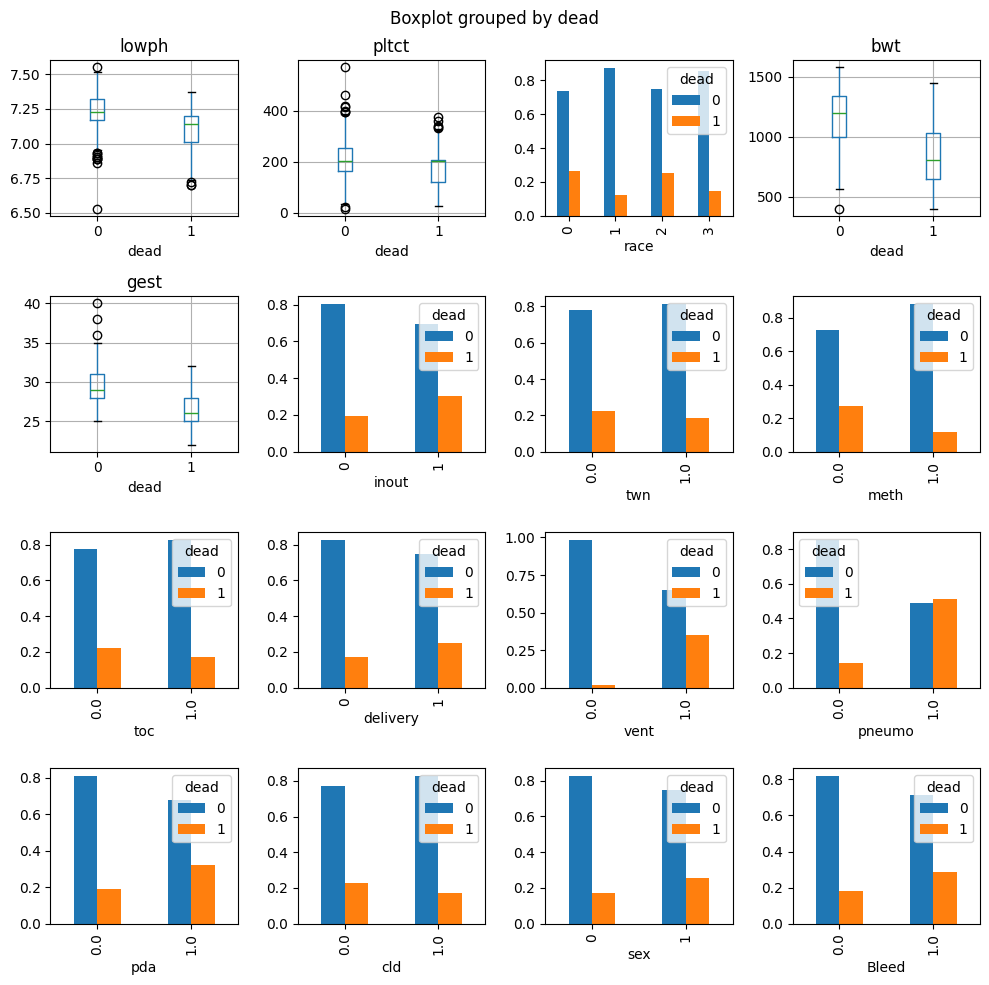

,0,1,2,3,4
0,T-test,lowph,dead,4.167358e-26,유의하다
1,T-test,pltct,dead,2.724723e-05,유의하다
2,카이제곱검정,race,dead,2.780301e-03,유의하다
3,T-test,bwt,dead,3.245787e-40,유의하다
4,T-test,gest,dead,7.113917e-44,유의하다
5,카이제곱검정,inout,dead,9.991527e-03,유의하다
6,카이제곱검정,twn,dead,4.154691e-01,유의하지 않다
7,카이제곱검정,meth,dead,4.578544e-06,유의하다
8,카이제곱검정,toc,dead,2.537098e-01,유의하지 않다
9,카이제곱검정,delivery,dead,1.516657e-02,유의하다


In [9]:
# dead를 종속변수로 가정하고 모델링에 적합하지 않다 생각하는 변수 제거 
from scipy import stats
y = 'dead'
X = c_df.drop(columns = y, axis = 1)

# 독립이다 (유의하지 않다)
# 독립이 아니다 (유의하다)

fig, axes = plt.subplots(4,4 , figsize = (10, 10))
res = []
for axes, col in zip(axes.flatten(), X.columns) : 
    if X[col].nunique() <= 4 : 
        tab = pd.crosstab(c_df[col] , c_df[y])
        stat, p, _, _ = chi2_contingency(tab)
        decision = '유의하다' if p < 0.05 else '유의하지 않다'
        res.append(['카이제곱검정', col, 'dead',p, decision])

        #시각화
        tab2 = pd.crosstab(c_df[col] , c_df[y], normalize = 'index')
        tab2.plot(kind = 'bar', ax= axes)

    else : 
        target = c_df.groupby('dead')[col].apply(list)
        s, p = stats.ttest_ind(target[0], target[1])
        decision = '유의하다' if p < 0.05 else '유의하지 않다'
        res.append(['T-test', col, 'dead',p, decision])

        #시각화
        c_df.boxplot(column = col, by = y, ax = axes)

plt.tight_layout()
plt.show()

display(pd.DataFrame(res))
remov_cols = ['twn', 'toc', 'cld'] 

In [10]:
# 1-5 
cols = ['dead', 'pvh', 'ivh', 'ipe']
m_df = df.drop(cols, axis = 1)

# Bleed 컬럼이 NaN인 행만 제거하기
m_df = m_df.dropna(subset= 'Bleed')

# 결측 처리 및 전처리 
clean_df = pd.DataFrame()
for col in m_df.columns : 
    if m_df[col].dtypes == 'object' or m_df[col].nunique() <= 3 : 
        clean_df[col] = m_df[col].fillna(m_df[col].mode()[0])

    else : 
        clean_df[col] = m_df[col].fillna(m_df[col].mean())

clean_df.isna().sum()
clean_df.head()


# 범주형 변수 변환
# f_df 생성시 인덱스 유지하기 
f_df = pd.DataFrame(index = clean_df.index)
for col in clean_df.columns : 
    if clean_df[col].dtypes == 'object' : 
        la = LabelEncoder()
        f_df[col] = la.fit_transform(clean_df[col])
    elif col in ['lowph','pltct','bwt','gest'] : 
        ss = StandardScaler()
        f_df[col] = ss.fit_transform(clean_df[[col]]).flatten() 
    else : 
        f_df[col] = clean_df[col]

f_df.head()


,lowph,pltct,race,bwt,gest,inout,twn,meth,toc,delivery,vent,pneumo,pda,cld,sex,Bleed,Ind
4,-1.692114e+00,-1.850400e+00,0,-0.588892,-0.316644,0,0.0,0.0,0.0,0,1.0,1.0,0.0,0.0,0,1.0,2
5,-2.243413e-02,-3.681102e-16,3,-0.530208,-0.316644,0,0.0,1.0,0.0,0,1.0,0.0,0.0,0.0,0,0.0,2
8,1.348146e-14,-3.681102e-16,0,-1.469157,-1.988329,0,0.0,0.0,0.0,1,1.0,0.0,0.0,0.0,1,0.0,2
12,-9.835075e-02,-1.925795e-01,0,0.134881,-0.316644,0,0.0,0.0,0.0,1,0.0,1.0,0.0,1.0,1,0.0,0
13,1.723117e+00,2.125779e+00,3,0.408741,-0.316644,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,1,0.0,0


In [11]:
train_set = f_df[f_df['Ind'] == 2].reset_index(drop = True).drop(columns = 'Ind', axis = 1)
x_train = train_set.drop(columns = 'Bleed', axis = 1)
y_train = train_set['Bleed']

test_set = f_df[f_df['Ind'] == 0].reset_index(drop = True).drop(columns = 'Ind', axis = 1)
x_test = test_set.drop(columns = 'Bleed', axis = 1)
y_test = test_set['Bleed']

,0,1,2
0,Decision,0.456790,0.545220
1,RandomForest,0.479532,0.540052



[Decision] 중요 변수 Top 2
bwt      0.199999
lowph    0.169055
dtype: float64

[RandomForest] 중요 변수 Top 2
bwt      0.190795
lowph    0.173803
dtype: float64


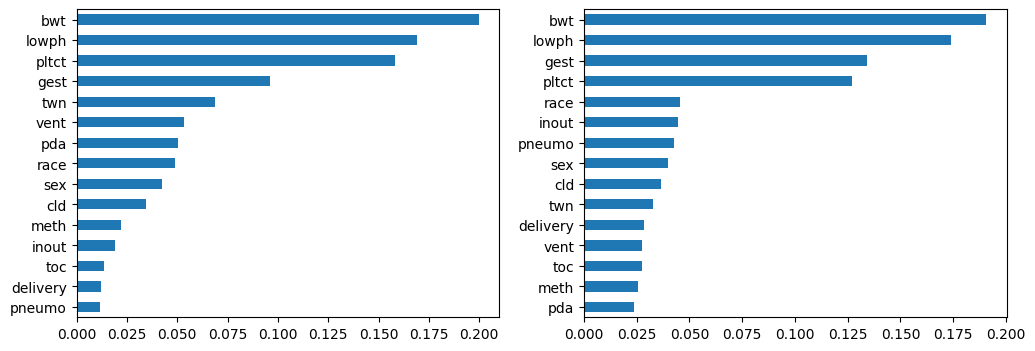

In [12]:
# 적절한 평가 지표 
# f1_score, accuracy_Score
# Bleed를 예측하기 위한 단일 알고리즘 모델과 앙상블 모델을 비교 분석 서술하시오
# 변수 중요도를 구해서 중요한 2개의 변수는 따로 출력한다. 
from sklearn.metrics import f1_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

def eval_model(name, model) : 
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    f1 = f1_score(y_test, pred)
    acc = accuracy_score(y_test, pred)

    return name, f1, acc 

res = []
mlst = []
for name, model in [['Decision', DecisionTreeClassifier()] , ['RandomForest', RandomForestClassifier()]] : 
    name, f1, acc = eval_model(name, model)
    res.append([name, f1, acc])
    mlst.append([name, model])

display(pd.DataFrame(res))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axes, (name, model) in zip(axes.flatten(), mlst) : 
    imp = pd.Series(model.feature_importances_, index = model.feature_names_in_).sort_values(ascending = True)
    imp.plot(kind = 'barh', ax = axes)

    #TOP2 
    print(f'\n[{name}] 중요 변수 Top 2')
    print(imp.sort_values(ascending = False).head(2))
    

In [13]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/ADP_SONY/ADP_34/data/m2_source.csv')
df.head(3)

,일자,자원,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,...,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,hour_24
0,2021-01-01,태양광,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.07,...,22.62,15.22,8.02,1.89,0.10,0.81,0.11,0.01,0.01,0.01
1,2021-01-01,풍력,119.64,105.18,106.19,76.71,65.16,79.13,47.67,39.37,...,29.19,27.11,23.78,19.02,36.62,24.00,19.66,14.78,23.45,21.14
2,2021-01-02,태양광,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.13,...,109.39,76.44,30.46,6.49,4.43,3.87,1.45,0.84,0.13,0.01


In [14]:
w = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/ADP_SONY/ADP_34/data/m2_weather.csv')
w.head()

,일시,기온,강수량,풍속,습도,일조,일사,적설,전운량,지면온도
0,2021_01_01@0,4.5,NaN,6.1,53.0,NaN,NaN,NaN,9.0,2.2
1,2021_01_01@1,4.3,NaN,5.6,58.0,NaN,NaN,NaN,9.0,2.4
2,2021_01_01@2,4.2,NaN,5.5,54.0,NaN,NaN,NaN,10.0,2.3
3,2021_01_01@3,4.3,0.0,5.4,52.0,NaN,NaN,NaN,10.0,2.2
4,2021_01_01@4,4.2,NaN,4.2,47.0,NaN,NaN,NaN,10.0,2.0


* 결측치가 존재하는 시간대의 동일 일자, 동일 자원 데이터의 직전 값과 다음 값의 평균으로 대치한다.
* 연속된 시간대의 결측치가 있다면 결측치가 아닌 이전 시간대의 값과 이후 시간대의 값의 평균으로 모든 연속 시간대 결측치를 대치한다.
* 맨앞이나 맨뒤에 결측치가 존재한다면 직전, 직후 시간대 값으로 대치

In [15]:
## df 처리 
df1 = df.copy()
hour_cols = [f'hour_{i}'for i in range(1,25)]
for col in hour_cols : 
    if df1[col].isna().any() & (col == 'hour_1') :
        df1[col] = df1[col].fillna(df1['hour_2'])        

    elif df1[col].isna().any() & (col == 'hour_24') : 
        df1[col] = df1[col].fillna(df1['hour_24']) 
        
    elif df1[col].isna().any() : 
        ffill = df1[hour_cols].ffill(axis = 1)[col]
        bfill = df1[hour_cols].bfill(axis = 1)[col]
        avg = (ffill + bfill) / 2 
        df1[col] = df1[col].fillna(avg)


* 결측치를 제거한 전력량 데이터에 대해 총전력량(태양광 + 풍력 발전량의 합)을 구한다.
* 동일 일자 동일 시간대에 대해 태양광과 풍력의 합을 구한다. 하나의 일자는 하나의 행에 시간대별 총전력량을 표현해야한다.
* 특정일자에 태양광 또는 풍력이 하나만 있는 경우에는 해당 자원의 전력량을 2배로 한다.

In [16]:
df2 = df1.copy()

pivot_df = df2.melt(id_vars = ['일자','자원'], var_name = 'hour' , value_name = '전력량').\
                        pivot_table(index = ['일자', 'hour'], 
                                   columns = '자원' , 
                                   values = '전력량').reset_index()
pivot_df['총전력량'] = pivot_df['태양광'] + pivot_df['풍력']
pivot_df.loc[pivot_df['총전력량'].isna()]

자원,일자,hour,태양광,풍력,총전력량
256,2021-01-11,hour_24,NaN,77.52,NaN
3304,2021-05-18,hour_24,0.42,NaN,NaN
12424,2022-06-02,hour_24,NaN,0.68,NaN
15712,2022-10-17,hour_24,0.16,NaN,NaN
18400,2023-02-06,hour_24,0.00,NaN,NaN
19648,2023-03-30,hour_24,0.39,NaN,NaN
20032,2023-04-15,hour_24,0.69,NaN,NaN
20896,2023-05-21,hour_24,NaN,14.84,NaN
22456,2023-07-25,hour_24,NaN,46.04,NaN
25024,2023-11-09,hour_24,0.00,NaN,NaN


In [17]:
#특정일자에 태양광 또는 풍력이 하나만 있는 경우에는 해당 자원의 전력량을 2배로 한다

def sun_wind(x) : 
    sun = pd.isna(x['태양광'])
    wind  = pd.isna(x['풍력'])

    if not sun and wind : 
        x['태양광'] * 2 
        x['풍력'] = 0 

    elif sun and not wind : 
        x['풍력'] * 2 
        x['태양광'] = 0 

    return x 
pivot_na_df = pivot_df.apply(sun_wind, axis = 1)

pivot_na_df.loc[pivot_na_df['총전력량'].isna()]

pivot_na_df['총전력량'] = pivot_na_df['태양광'] + pivot_na_df['풍력']
pivot_na_df

자원,일자,hour,태양광,풍력,총전력량
0,2021-01-01,hour_1,0.00,119.64,119.64
1,2021-01-01,hour_10,16.81,31.86,48.67
2,2021-01-01,hour_11,44.53,30.40,74.93
3,2021-01-01,hour_12,52.61,15.22,67.83
4,2021-01-01,hour_13,39.06,18.47,57.53
...,...,...,...,...,...
26275,2023-12-31,hour_5,0.00,150.62,150.62
26276,2023-12-31,hour_6,0.00,196.13,196.13
26277,2023-12-31,hour_7,0.00,217.37,217.37
26278,2023-12-31,hour_8,0.17,218.39,218.56


* 파생변수를 생성한다.
* 변수명 season
* 3-5월 0, 6-8월 1, 9-10월 2, 11-12월 3
* 참고 : 실제 시험에서 1,2월에 대한 언급이 없었음, (풀이에 관련 언급을 하고 해당 데이터 제거하고 풀기)

In [18]:
power = pivot_na_df.copy()
power['hour'] = (power['hour'].str.split('_').str[1].astype(int) - 1 ).astype(str).str.zfill(2)

power['일자'] =  pd.to_datetime( power['일자'] + ' ' + power['hour']  )

In [19]:
power = power[['일자', '총전력량']].reset_index(drop =True)
power.columns.name = ''

power['season'] = np.where(
                            power['일자'].dt.month.isin([3,4,5]) , 0 , 
                            np.where(
                                power['일자'].dt.month.isin([9,10]) , 2 , 
                                np.where(
                                    power['일자'].dt.month.isin([11,12]) , 3 , np.nan 
                                )
                            )
                        )
power = power.dropna().reset_index(drop = True)

In [20]:
power

,일자,총전력량,season
0,2021-03-01 00:00:00,99.59,0.0
1,2021-03-01 09:00:00,197.68,0.0
2,2021-03-01 10:00:00,202.18,0.0
3,2021-03-01 11:00:00,186.44,0.0
4,2021-03-01 12:00:00,205.36,0.0
...,...,...,...
15403,2023-12-31 04:00:00,150.62,3.0
15404,2023-12-31 05:00:00,196.13,3.0
15405,2023-12-31 06:00:00,217.37,3.0
15406,2023-12-31 07:00:00,218.56,3.0


In [21]:
# w 데이터 처리 

# 년-월-일 시간
w['일시'] = pd.to_datetime(
w['일시'].str.split('@').str[0].str.replace('_','-') + ' ' + w['일시'].str.split('@').str[1].str.zfill(2)
)

* 기상데이터의 결측치를 처리한다
* 강수량, 일조, 일사, 적설은 0으로 채운다.
* 풍속, 습도는 직전값으로 전운량과 지면온도는 전체 평균값으로 대치한다.

In [22]:
w['강수량'].fillna(0, inplace = True)
w['일조'].fillna(0, inplace = True)
w['일사'].fillna(0, inplace = True)
w['적설'].fillna(0, inplace = True)

In [23]:
# 풍속, 습도 
w['풍속'].fillna(method = 'ffill', inplace = True)
w['습도'].fillna(method = 'ffill', inplace = True)

# 전운량, 지면온도
w['전운량'].fillna(w['전운량'].mean(), inplace = True)
w['지면온도'].fillna(w['지면온도'].mean(), inplace = True)

In [24]:
w.head()

,일시,기온,강수량,풍속,습도,일조,일사,적설,전운량,지면온도
0,2021-01-01 00:00:00,4.5,0.0,6.1,53.0,0.0,0.0,0.0,9.0,2.2
1,2021-01-01 01:00:00,4.3,0.0,5.6,58.0,0.0,0.0,0.0,9.0,2.4
2,2021-01-01 02:00:00,4.2,0.0,5.5,54.0,0.0,0.0,0.0,10.0,2.3
3,2021-01-01 03:00:00,4.3,0.0,5.4,52.0,0.0,0.0,0.0,10.0,2.2
4,2021-01-01 04:00:00,4.2,0.0,4.2,47.0,0.0,0.0,0.0,10.0,2.0


In [25]:
f_df = pd.merge(power, w, how = 'left' , left_on = '일자' , right_on = '일시').drop(columns = '일시', axis = 1)
f_df

,일자,총전력량,season,기온,강수량,풍속,습도,일조,일사,적설,전운량,지면온도
0,2021-03-01 00:00:00,99.59,0.0,16.6,0.0,4.6,73.0,0.0,0.00,0.0,6.0,12.3
1,2021-03-01 09:00:00,197.68,0.0,17.5,0.0,1.1,79.0,0.0,0.09,0.0,10.0,14.0
2,2021-03-01 10:00:00,202.18,0.0,18.5,0.0,3.1,79.0,0.0,0.20,0.0,10.0,15.7
3,2021-03-01 11:00:00,186.44,0.0,20.0,0.0,3.5,69.0,0.1,0.58,0.0,10.0,17.7
4,2021-03-01 12:00:00,205.36,0.0,20.8,0.1,3.2,64.0,0.0,0.17,0.0,10.0,15.9
...,...,...,...,...,...,...,...,...,...,...,...,...
15403,2023-12-31 04:00:00,150.62,3.0,12.6,0.0,6.2,60.0,0.0,0.00,0.0,9.0,9.8
15404,2023-12-31 05:00:00,196.13,3.0,12.6,0.0,7.1,60.0,0.0,0.00,0.0,8.0,9.5
15405,2023-12-31 06:00:00,217.37,3.0,11.4,0.0,10.1,68.0,0.0,0.00,0.0,8.0,9.5
15406,2023-12-31 07:00:00,218.56,3.0,10.9,0.0,9.5,63.0,0.0,0.00,0.0,8.0,8.5


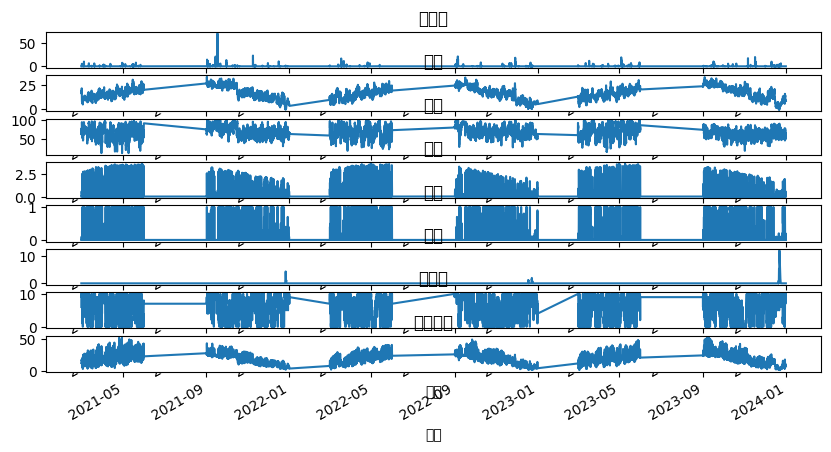

In [26]:
# 전처리 완료된 데이터의 기술 통계량 및 EDA를 실시하라 
fig, axes = plt.subplots(8, 1, figsize = (10, 5))

for axes, col in zip(axes.flatten(), f_df.columns.difference(['일자','season'])) : 
    target = f_df.groupby('일자')[col].mean() 
    target.plot(kind = 'line', ax = axes)
    axes.set_title(col)

plt.tight_layout()
plt.show()

# 일주일 평균을 살펴봤을 때 계절성 주기성을 보인다. 계절, 월별값에 대해 수치형 변수에 대한 평균값을 비교해 볼 수 있다.

2-3
* 전력량을 종속변수로 하고 종속변수와 다른 연속형 변수들간의 상관관계 분석을 진행하라. 유의확률을 포함하여 분석결과를 서술하라.
* season에 따라 종속변수간의 차이가 있는지 통계적으로 확인하고 분석결과를 서술하라

In [27]:
from scipy.stats import pearsonr

df_cor  = f_df.drop(columns = '일자', axis = 1)

res = []
for col in df_cor .columns : 
    cor, p = pearsonr(df_cor ['총전력량'], df_cor [col])
    d = '유의하지않다' if p < 0.05 else '유의하다'
    res.append([col , '총전력량', p, d])

pd.DataFrame(res)

,0,1,2,3
0,총전력량,총전력량,0.000000e+00,유의하지않다
1,season,총전력량,8.774484e-01,유의하다
2,기온,총전력량,3.956514e-06,유의하지않다
3,강수량,총전력량,5.503514e-02,유의하다
4,풍속,총전력량,0.000000e+00,유의하지않다
5,습도,총전력량,1.667995e-318,유의하지않다
6,일조,총전력량,0.000000e+00,유의하지않다
7,일사,총전력량,0.000000e+00,유의하지않다
8,적설,총전력량,4.789334e-01,유의하다
9,전운량,총전력량,5.689095e-03,유의하지않다


In [28]:
#season에 따라 종속변수간의 차이가 있는지 통계적으로 확인하고 분석결과

from scipy import stats
res = []
for col in df_cor.columns.difference(['일자','season']) :

    group = [group[col] for name, group in f_df.groupby('season')]
    s, p = stats.f_oneway(* group)
    d = '적어도 하나의 season에서는 다르다' if p < 0.05 else 'season별 차이가 없다' 

    res.append([col, p, d])
    
print(pd.DataFrame(res))



      0              1                      2
0   강수량   4.904234e-08  적어도 하나의 season에서는 다르다
1    기온   0.000000e+00  적어도 하나의 season에서는 다르다
2    습도  6.518785e-102  적어도 하나의 season에서는 다르다
3    일사  3.469172e-143  적어도 하나의 season에서는 다르다
4    일조   2.172012e-77  적어도 하나의 season에서는 다르다
5    적설   1.295214e-40  적어도 하나의 season에서는 다르다
6   전운량   2.394450e-21  적어도 하나의 season에서는 다르다
7  지면온도   0.000000e+00  적어도 하나의 season에서는 다르다
8  총전력량   2.264206e-11  적어도 하나의 season에서는 다르다
9    풍속  2.918332e-143  적어도 하나의 season에서는 다르다


In [29]:
f_df

,일자,총전력량,season,기온,강수량,풍속,습도,일조,일사,적설,전운량,지면온도
0,2021-03-01 00:00:00,99.59,0.0,16.6,0.0,4.6,73.0,0.0,0.00,0.0,6.0,12.3
1,2021-03-01 09:00:00,197.68,0.0,17.5,0.0,1.1,79.0,0.0,0.09,0.0,10.0,14.0
2,2021-03-01 10:00:00,202.18,0.0,18.5,0.0,3.1,79.0,0.0,0.20,0.0,10.0,15.7
3,2021-03-01 11:00:00,186.44,0.0,20.0,0.0,3.5,69.0,0.1,0.58,0.0,10.0,17.7
4,2021-03-01 12:00:00,205.36,0.0,20.8,0.1,3.2,64.0,0.0,0.17,0.0,10.0,15.9
...,...,...,...,...,...,...,...,...,...,...,...,...
15403,2023-12-31 04:00:00,150.62,3.0,12.6,0.0,6.2,60.0,0.0,0.00,0.0,9.0,9.8
15404,2023-12-31 05:00:00,196.13,3.0,12.6,0.0,7.1,60.0,0.0,0.00,0.0,8.0,9.5
15405,2023-12-31 06:00:00,217.37,3.0,11.4,0.0,10.1,68.0,0.0,0.00,0.0,8.0,9.5
15406,2023-12-31 07:00:00,218.56,3.0,10.9,0.0,9.5,63.0,0.0,0.00,0.0,8.0,8.5


2-4 아래 기준으로 회귀모델링을 진행하고 평가하라.
* 21년,22년도를 학습데이터, 23년도를 평가데이터로 사용한다.
* RMSE를 포함한 적절한 평가지표 2가지로 판단
* 일반 회귀모형 1개, 기계학습 모델 1개로 진행한다.

3-1 성별,교육방법에 따른 성적의 차이가 존재하는지 확인하려한다. 가설 검정 전 필요한 사전 가정을 설명하고 확인하라.

* between 요인 2그룹  → ttest_ind
* between 요인 3그룹+ → f_oneway + pairwise_tukeyhsd

* within 요인 2수준   → ttest_rel  (대응표본)
* within 요인 3수준+  → pg.pairwise_ttests (Bonferroni)

In [39]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/ADP_SONY/ADP_34/data/student_scores.csv')
df.head(10)

#df.info()

,id,성별,traindition,online,mix
0,1,Male,69,74,68
1,2,Male,59,65,63
2,3,Male,60,75,63
3,4,Male,79,52,76
4,5,Male,100,77,67
5,6,Male,84,55,49
6,7,Male,83,60,52
7,8,Male,56,64,66
8,9,Male,71,84,74
9,10,Male,83,63,59


In [35]:
# wide - long 변환 
df_long = df.melt(id_vars  = ['id','성별'] , 
                    var_name = '교육방법', 
                    value_name = '점수')
df_long.head()

,id,성별,교육방법,점수
0,1,Male,traindition,69
1,2,Male,traindition,59
2,3,Male,traindition,60
3,4,Male,traindition,79
4,5,Male,traindition,100


In [47]:
import pingouin as pg

# 1.정규성 (성별 + 교육방법)
# 성별 + 교육방법 
res = []

for g in df_long['성별'].unique() : 
    for m in df_long['교육방법'].unique() : 

        group = df_long[(df_long['성별'] == g) & (df_long['교육방법'] == m )]['점수']
        stat, p = stats.shapiro(group)
        d = '정규분포가 아니다' if p <  0.05 else '정규분포이다' 
        res.append([g, m, p, d])

print(pd.DataFrame(res))

# 2.등분산성
# Between 요인(성별 기준)
groups = [df_long[df_long['성별'] == g]['점수'] for g in df_long['성별'].unique()]
stat, p = stats.levene(*groups)
d = '등분산성 아니다' if p <  0.05 else '등분산이다'
print(p, d)

# 3. 구형성 - 교육방법의 분산의 차이가 일정한가. 
# Within 교육방법 기준- 3수준 일떄만 의미가 있음 

spher = pg.sphericity(data = df_long , 
                 dv = '점수' , 
                 subject = 'id', 
                 within = '교육방법')
print(spher)
print('만족' if spher.pval > 0.05 else '위반 → Greenhouse-Geisser 보정 필요')

        0            1         2          3
0    Male  traindition  0.097687     정규분포이다
1    Male       online  0.683060     정규분포이다
2    Male          mix  0.083163     정규분포이다
3  Female  traindition  0.472527     정규분포이다
4  Female       online  0.048999  정규분포가 아니다
5  Female          mix  0.994322     정규분포이다
0.4313202535973647 등분산이다
SpherResults(spher=True, W=np.float64(0.9755189917040903), chi2=np.float64(0.9418547160194226), dof=2, pval=np.float64(0.6244229360888147))
만족


3-2 통계검정을 진행 후 검정 후 주효과, 상호작용 검정을 진행하라

In [64]:
# 귀무가설 : 성별, 교육방법에 따른 성적의 차이가 없다
# 대립가설 : 성별, 교육방법에 따른 성적의 차이가 있다. 

# ----- Mixed ANOVA ------------- 
aov = pg.mixed_anova(dv = '점수' , 
                     within = '교육방법', 
                     between = '성별', 
                     subject = 'id' , 
                     data = df_long)
print(aov)






        Source          SS  DF1  DF2         MS         F     p-unc       np2  \
0           성별   22.533333    1   38  22.533333  0.199343  0.657785  0.005219   
1         교육방법  117.650000    2   76  58.825000  0.482945  0.618844  0.012550   
2  Interaction   50.516667    2   76  25.258333  0.207367  0.813179  0.005427   

        eps  
0       NaN  
1  0.976104  
2       NaN  


```python
# 2) 3요인인 경우라면,  3그룹 이상 → ANOVA + Tukey
    group_list = [
        df_long[df_long['성별'] == g]['점수']
        for g in groups
    ]
    f, p = stats.f_oneway(*group_list)
    print(f'F={f:.4f}  p={p:.4f}  {"유의" if p<0.05 else "비유의"}')

    if p < 0.05:
        tukey = pairwise_tukeyhsd(
            endog  = df_long['점수'],
            groups = df_long['성별'],
            alpha  = 0.05
        )
        print(tukey.summary()
```

3-3 주 효과에 대한 사후검정을 진행

  Contrast       A            B  Paired  Parametric         T   dof  \
0     교육방법     mix       online    True        True -0.514835  39.0   
1     교육방법     mix  traindition    True        True  0.478733  39.0   
2     교육방법  online  traindition    True        True  1.000655  39.0   

  alternative     p-unc    p-corr p-adjust   BF10    hedges  
0   two-sided  0.609574  1.000000     bonf  0.193 -0.107786  
1   two-sided  0.634802  1.000000     bonf   0.19  0.112853  
2   two-sided  0.323162  0.969487     bonf  0.272  0.226435  


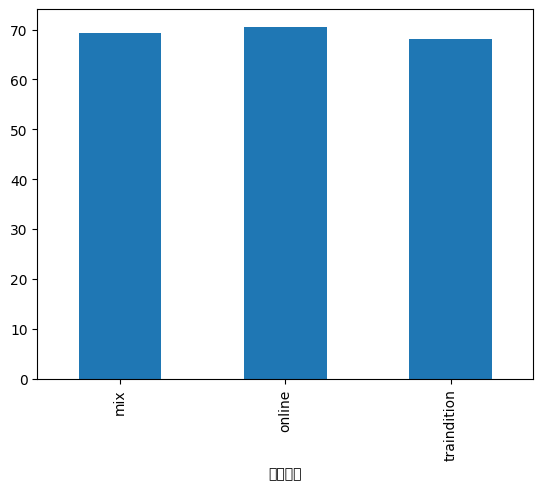

In [65]:
# 주효과 검정 
# 1) 교육방법 사후검정
post_within = pg.pairwise_ttests(
                                    dv = '점수', 
                                    within = '교육방법', 
                                    subject = 'id',
                                    data = df_long, 
                                    padjust = 'bonf'
)
print(post_within) 

# 교육방법 주효과 시각화
mean = df_long.groupby('교육방법')['점수'].mean()
mean.plot(kind = 'bar')
plt.show()




성별 사후 검정 (t-test)
t=-0.4402  p=0.6606  비유의


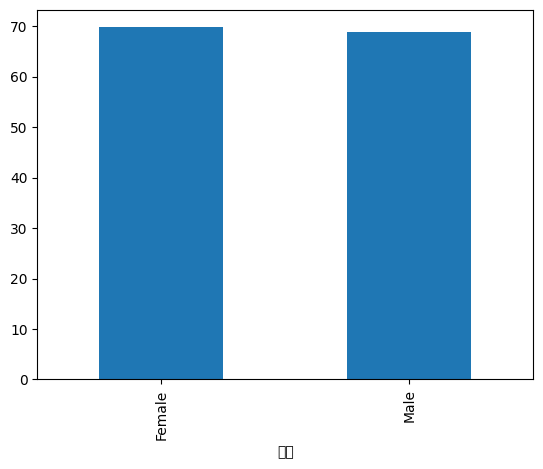

In [66]:
# 2) 성별 주효과 사후검정 (2요인)
print('''성별 사후 검정 (t-test)''')
male   = df_long[df_long['성별'] == 'Male']['점수']
female = df_long[df_long['성별'] == 'Female']['점수']
t, p   = stats.ttest_ind(male, female)
print(f't={t:.4f}  p={p:.4f}  {"유의" if p < 0.05 else "비유의"}')

# 성별 주효과 시각화
mean = df_long.groupby('성별')['점수'].mean()
mean.plot(kind = 'bar')
plt.show()



In [80]:
# 상호작용 유의 여부에 따라 묻기
inter_p = aov.loc[aov['Source'] == 'Interaction', 'p-unc'].values[0]
gender_p = aov.loc[aov['Source'] == '성별', 'p-unc'].values[0]
edu_p = aov.loc[aov['Source'] == '교육방법', 'p-unc'].values[0]

if inter_p < 0.05 : 
    print('상호작용 유의 -> 단순효과검정')

    #성별 고정 -> 교육방법 비교 
    for g in df_long['성별'].unique() : 
        sub = df_long[df_long['성별'] == g]
        tukey = pg.pairwise_ttests(dv = '점수' , 
                                   between = '교육방법' , 
                                   subject = 'id', 
                                   data = df_long, 
                                   padjust = 'bonf')
        print(tukey[['A','B','p-corr']])

    # 교육방법 고정 -> 성별 비교 
    for m in df_long['교육방법'].unique() : 
        sub = df_long[df_long['교육방법'] == m]

        m = df_long[df_long['성별'] == 'Male']['점수']
        f = df_long[df_long['성별'] == 'Female']['점수']

        stat, p = stats.ttest_ind(m, f)
        print(p)


elif gender_p < 0.05 : 
    print('상호작용없음 -> 주효과검정')

    #교육효과의 주효과가 유의하면 ->> Tukey
    tukey = pg.pairwise_ttests(dv = '점수' , 
                              between = '교육방법', 
                              subject = 'id', 
                              data = df_long , 
                              padjust = 'bonf')

elif edu_p < 0.05 :
    # 성별의 주효과가 유의하면 
    group = df_long.groupby('성별')['점수'].apply(list)
    s, p = stats.ttest_ind(group[0] , group[1])
    print(p)





4-1 회귀모델이 유의한지 F검정에 대한 분석 및 결정계수 제시 및 해석

In [100]:
import statsmodels.api as sm 


df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_DE2/refs/heads/main/ADP_SONY/ADP_34/data/s4.csv')
df.head()

,ID,studytime,failures,schoolsup,famsup,absences,score
0,ID_1,2,0,yes,no,4,11
1,ID_2,2,0,no,yes,2,11
2,ID_3,2,0,yes,no,6,13
3,ID_4,3,0,no,yes,0,14
4,ID_5,2,0,no,yes,0,13


In [101]:
df['schoolsup'] = df['schoolsup'].map({'yes':1,'no':0})
df['famsup'] = df['famsup'].map({'yes':1,'no':0})

X = df.drop(columns = ['ID', 'score'], axis = 1)
y = df['score']

add_x = sm.add_constant(X)
m = sm.OLS(y, X).fit()
print(m.summary())

                                 OLS Regression Results                                
Dep. Variable:                  score   R-squared (uncentered):                   0.857
Model:                            OLS   Adj. R-squared (uncentered):              0.856
Method:                 Least Squares   F-statistic:                              771.8
Date:                Thu, 16 Apr 2026   Prob (F-statistic):                   3.78e-269
Time:                        15:30:26   Log-Likelihood:                         -1898.8
No. Observations:                 649   AIC:                                      3808.
Df Residuals:                     644   BIC:                                      3830.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

4-2 잔차를 통해 회귀모델의 유의성 검정

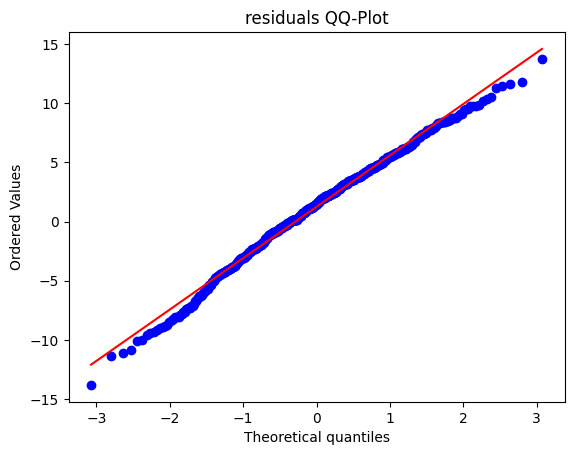

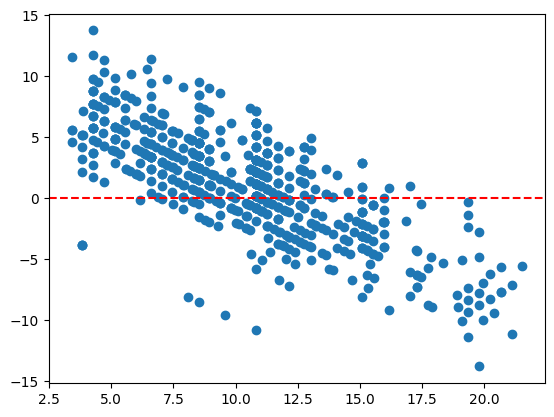

In [107]:
from statsmodels.stats.stattools import durbin_watson
resid = m.resid
fit = m.fittedvalues 

# 잔차의 정규성 QQplot 
stats.probplot(resid, dist = 'norm', plot= plt)
plt.title("residuals QQ-Plot")
plt.show()

# 등분산성 - 잔차 , 예측값 산점도 
plt.scatter(fit, resid)
plt.axhline(0, color = 'red', linestyle = '--') 


# 독립성- 더빈 왓슨
d = stats.durbin_watson(resid)
print(d)

#선형성 

4-3 다중공선성이 있는지 VIF로 측정 및 확인 및 제언

In [110]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['col'] = X.columns 
vif['vif'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

         col       vif
0  studytime  2.584695
1   failures  1.129932
2  schoolsup  1.132317
3     famsup  2.437308
4   absences  1.501333


4-4 회귀계수 및 검정 결과로 가장 유의한 변수 무엇인지 설명하

In [113]:
m.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
studytime,4.2560,0.136,31.284,0.000,3.989,4.523
failures,-0.4282,0.299,-1.434,0.152,-1.015,0.158
schoolsup,-0.2586,0.584,-0.442,0.658,-1.406,0.889
famsup,2.3291,0.354,6.571,0.000,1.633,3.025
absences,0.2191,0.037,5.941,0.000,0.147,0.292
